Input directory: ['HPG-MxP-WeakScaling/mxp/1', 'HPG-MxP-WeakScaling/ref/1', 'HPG-MxP-WeakScaling/mxp/2', 'HPG-MxP-WeakScaling/ref/2', 'HPG-MxP-WeakScaling/mxp/4', 'HPG-MxP-WeakScaling/ref/4', 'HPG-MxP-WeakScaling/mxp/8', 'HPG-MxP-WeakScaling/ref/8', 'HPG-MxP-WeakScaling/mxp/16', 'HPG-MxP-WeakScaling/ref/16', 'HPG-MxP-WeakScaling/mxp/32', 'HPG-MxP-WeakScaling/ref/32', 'HPG-MxP-WeakScaling/mxp/64', 'HPG-MxP-WeakScaling/ref/64']
EDP alpha: 1.0
EDP beta: 1.0
Loading file: HPG-MxP-WeakScaling/mxp/1/job_output.log
Loading data for frequency_cap: 1700.0
 duration: 221  secs    energy: 0.0965  KWh
Loading data for frequency_cap: 1600.0
 duration: 210  secs    energy: 0.0923  KWh
Loading data for frequency_cap: 1500.0
 duration: 211  secs    energy: 0.0896  KWh
Loading data for frequency_cap: 1400.0
 duration: 213  secs    energy: 0.0872  KWh
Loading data for frequency_cap: 1300.0
 duration: 213  secs    energy: 0.0854  KWh
Loading data for frequency_cap: 1200.0
 duration: 214  secs    energy: 

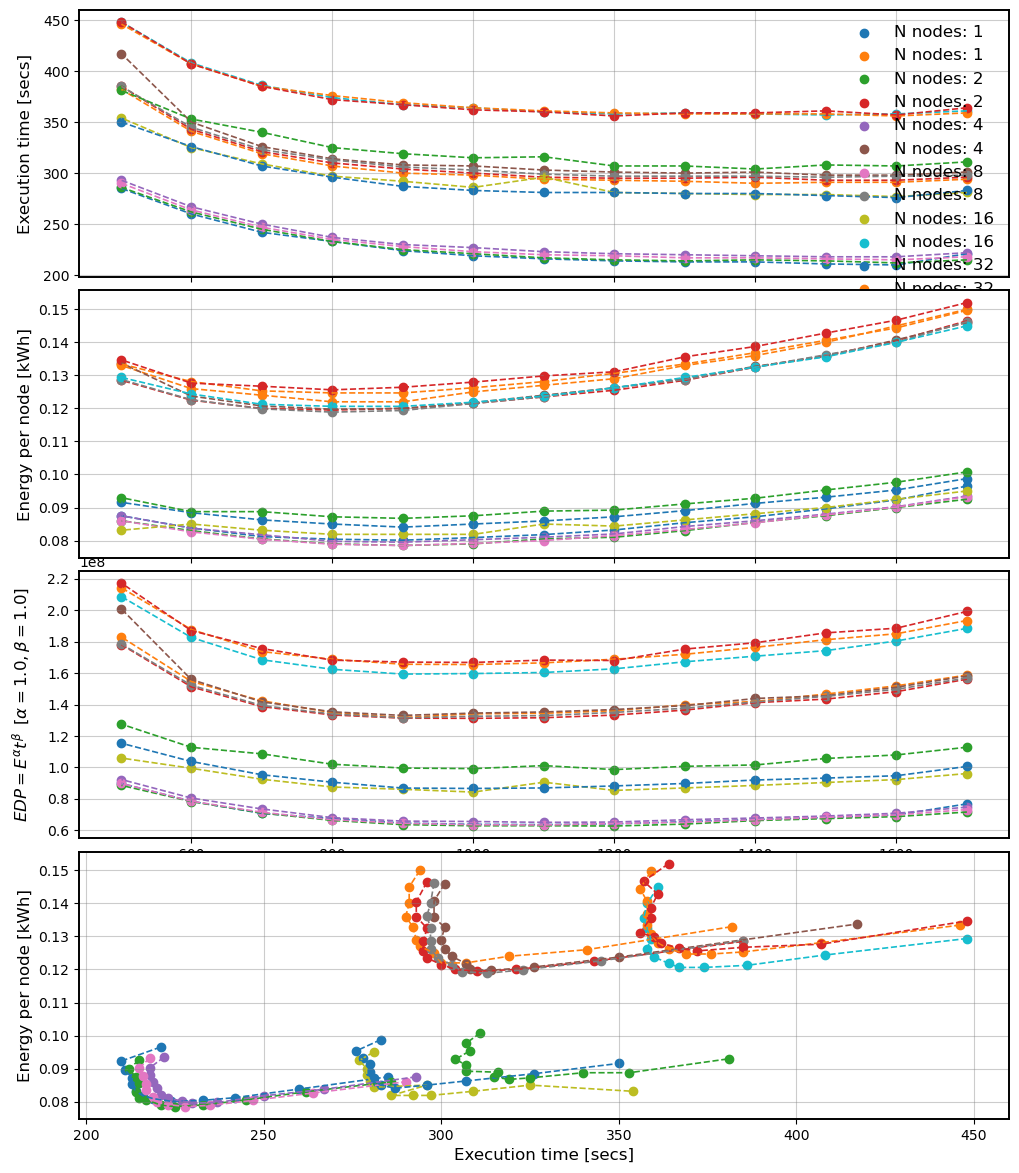

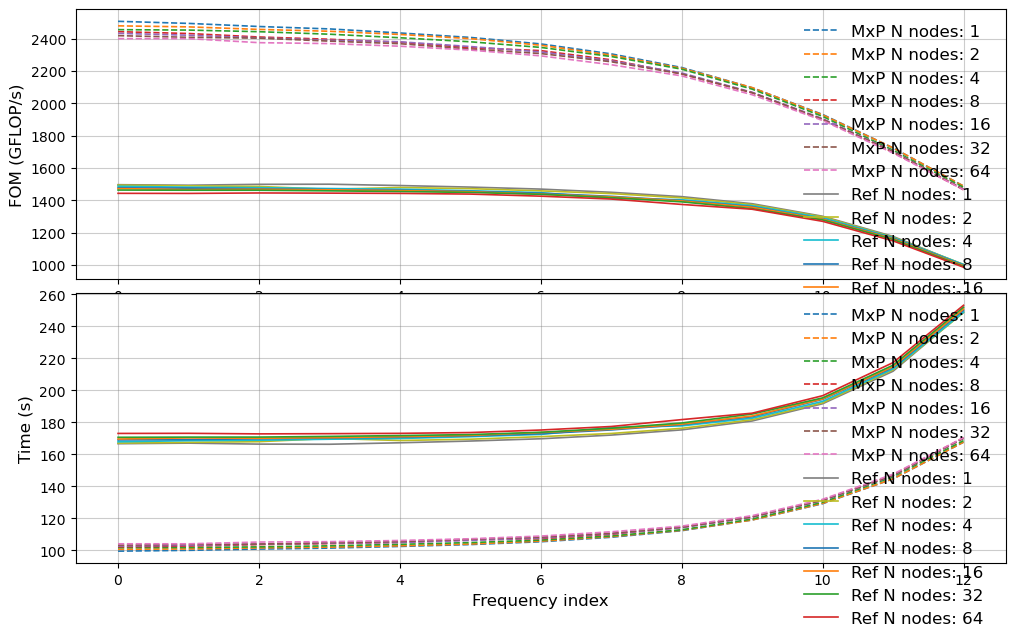

In [1]:
import os, glob
import numpy as np
import importlib
import tools.parse_benchmark_output as benchmark_tools
import tools.analysis_tools as tools
import scripts.energy_analysis as scripts
importlib.reload(benchmark_tools)
importlib.reload(tools)
importlib.reload(scripts)

def benchmark_data(dirs):
    benchmark_data = {}
    for indx_dir,dir in enumerate(dirs):
        if (dir.find("ref") != -1):
            flops_key = "double_total_gflops"
            time_key = "double_total_time"
        elif (dir.find("mxp") != -1):
            flops_key = "mxp_total_gflops"
            time_key = "mxp_total_time"
        else:
            raise "Invalid extraction type!"
            
        # List benchmark output files
        pattern = os.path.join(dir, 'HPGMP-Benchmark*')
        matching_files = glob.glob(pattern)
        sorted_files = sorted(matching_files, key=os.path.getmtime)

        # Loop through files and extract results
        n_nodes_list = []
        gflops_per_node_list = []
        time_list = []
        for indx,file_name in enumerate(sorted_files):
            results = benchmark_tools.parse_iterations_summary(file_path=file_name, extr_type="flops")
            n_nodes = results["n_procs"]/8
            gflops_per_node = results[flops_key]/n_nodes
            time = results[time_key]
            n_nodes_list.append(round(n_nodes))
            gflops_per_node_list.append(gflops_per_node)
            time_list.append(time)

        benchmark_data[indx_dir] = {'indx': indx_dir, 'n_nodes': n_nodes_list, 'FOM': gflops_per_node_list, 'Time': time_list}
        
    return benchmark_data

# Job overall name
name = "HPG-MxP-WeakScaling"

# Set directories
dirs     = []
dirs_ref = []
dirs_mxp = []
powers = np.arange(0, 7)
for power in powers:
    nnode = 2**power
    dir_mxp = name+"/mxp/{}".format(nnode)
    dir_ref = name+"/ref/{}".format(nnode)
    dirs_mxp.append(dir_mxp)
    dirs_ref.append(dir_ref)
    dirs.append(dir_mxp)
    dirs.append(dir_ref)

# Get telemetry data
edp_alpha = 1.0
edp_beta = 1.0
data = scripts.energy_analysis(dirs, edp_alpha, edp_beta, False, True)
data_mxp = scripts.energy_analysis(dirs_mxp, edp_alpha, edp_beta, False, False)
data_ref = scripts.energy_analysis(dirs_ref, edp_alpha, edp_beta, False, False)

# Get benchmark data and plot
benchmark_data_mxp = benchmark_data(dirs_mxp)
benchmark_data_ref = benchmark_data(dirs_ref)
tools.plot_benchmark_data(benchmark_data_mxp, benchmark_data_ref)

# Save to csv
csv_file_mxp = name+"-mxp.csv"
if os.path.exists(csv_file_mxp):
    os.remove(csv_file_mxp)
tools.save_frequency_cap_energy_analysis(data_mxp, edp_alpha, edp_beta, csv_file_mxp, multiple_data=True, FOM_data=benchmark_data_mxp)

csv_file_ref = name+"-ref.csv"
if os.path.exists(csv_file_ref):
    os.remove(csv_file_ref)
tools.save_frequency_cap_energy_analysis(data_ref, edp_alpha, edp_beta, csv_file_ref, multiple_data=True, FOM_data=benchmark_data_ref)